<a href="https://colab.research.google.com/github/introvet7/ksvd/blob/main/%D0%9B%D0%A02_%D0%9A%D0%B8%D1%8F%D1%88%D0%BA%D0%BE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Кияшко Ілля ФІТ 3-8
ФІТ 3-8, КСВД ЛР-2\
*Вибачте що не як на парі виконано(Хоча я і був, не було світла разом з вами виконувать), тому я виконав по файлу*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
from google.colab import files

uploaded = files.upload()



Saving bestsellers.csv to bestsellers (2).csv


# **Global YouTube Statistics 2023**

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Global YouTube Statistics.csv to Global YouTube Statistics (1).csv


Перші 5 рядків YouTube датасету


,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880



Розмір датасету: (995, 28)

Кількість пропусків до обробки 
rank                                         0
Youtuber                                     0
subscribers                                  0
video views                                  0
category                                    46
Title                                        0
uploads                                      0
Country                                    122
Abbreviation                               122
channel_type                                30
video_views_rank                             1
country_rank                               116
channel_type_rank                           33
video_views_for_the_last_30_days            56
lowest_monthly_earnings                      0
highest_monthly_earnings                     0
lowest_yearly_earnings                       0
highest_yearly_earnings                      0
subscribers_for_last_30_days               337
created_year                                 5

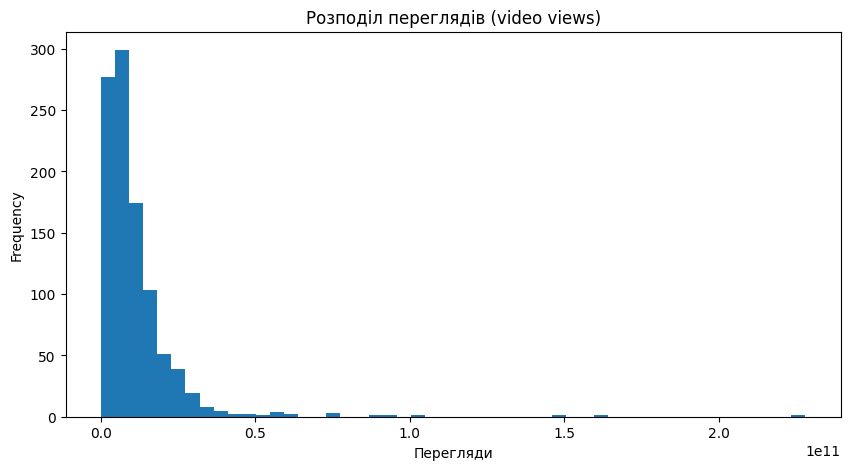


Максимальна кількість переглядів: 228000000000.0
Мінімальна кількість переглядів: 0.0
Середня кількість переглядів: 11039537052.04

Країна з найбільшою кількістю завантажень: India

Канал з найбільшою кількістю завантажень: ABP NEWS
Канал з найменшою кількістю завантажень: Music


In [ ]:
file_name = 'Global YouTube Statistics (1).csv'
df_yt = pd.read_csv(file_name, encoding='latin-1')


print("Перші 5 рядків YouTube датасету")
display(df_yt.head())

print(f"\nРозмір датасету: {df_yt.shape}")

print("\nКількість пропусків до обробки ")
print(df_yt.isna().sum())

df_yt.replace(['NaN', 'nan', '', ' '], np.nan, inplace=True)

numeric_cols = df_yt.select_dtypes(include=[np.number]).columns
df_yt[numeric_cols] = df_yt[numeric_cols].astype(float)
df_yt[numeric_cols] = df_yt[numeric_cols].fillna(df_yt[numeric_cols].mean())

print("\n--- Пропуски після обробки (в числових колонках) ---")
print(df_yt[numeric_cols].isna().sum())

unique_countries = df_yt['Country'].nunique()
print(f"\nКількість унікальних країн: {unique_countries}")

df_yt['video views'].plot(kind='hist', bins=50, title='Розподіл переглядів (video views)', figsize=(10,5))
plt.xlabel('Перегляди')
plt.show()

print(f"\nМаксимальна кількість переглядів: {df_yt['video views'].max()}")
print(f"Мінімальна кількість переглядів: {df_yt['video views'].min()}")
print(f"Середня кількість переглядів: {df_yt['video views'].mean():.2f}")

country_most_uploads = df_yt.groupby('Country')['uploads'].sum().idxmax()
print(f"\nКраїна з найбільшою кількістю завантажень: {country_most_uploads}")

max_uploads_channel = df_yt.loc[df_yt['uploads'].idxmax(), 'Youtuber']
min_uploads_channel = df_yt.loc[df_yt['uploads'].idxmin(), 'Youtuber']
print(f"\nКанал з найбільшою кількістю завантажень: {max_uploads_channel}")
print(f"Канал з найменшою кількістю завантажень: {min_uploads_channel}")

# **Amazon Top 50 Bestselling Books**

In [ ]:
df_books = pd.read_csv('bestsellers.csv')

print("--- Перші 10 рядків ---")
display(df_books.head(10))

print(f"\nРозміри датасету: {df_books.shape}")

print(f"Датасет зберігає дані про {df_books.shape[0]} книг.")

df_books.columns = ['name', 'author', 'user_rating', 'reviews', 'price', 'year', 'genre']

print("\n--- Кількість пропусків у стовпчиках ---")
print(df_books.isna().sum())

has_missing = "Так" if df_books.isna().any().any() else "Ні"
print(f"Чи є пропуски в даних? {has_missing}")

unique_genres = df_books['genre'].unique()
print(f"\nУнікальні жанри: {', '.join(unique_genres)}")

print(f"\nМаксимальна ціна: {df_books['price'].max()}")
print(f"Мінімальна ціна: {df_books['price'].min()}")
print(f"Середня ціна: {df_books['price'].mean():.2f}")
print(f"Медіанна ціна: {df_books['price'].median()}")

print("\n--- Пошук і сортування ---")
max_rating = df_books['user_rating'].max()
print(f"Найвищий рейтинг: {max_rating}")

books_with_max_rating = df_books[df_books['user_rating'] == max_rating].shape[0]
print(f"Кількість книг з найвищим рейтингом: {books_with_max_rating}")

most_reviewed_book = df_books.loc[df_books['reviews'].idxmax(), 'name']
print(f"Книга з найбільшою кількістю відгуків: {most_reviewed_book}")

books_2010 = df_books[df_books['year'] == 2010]
most_expensive_2010 = books_2010.loc[books_2010['price'].idxmax(), 'name']
print(f"Найдорожча книга з Топ-50 у 2010 році: {most_expensive_2010}")

fiction_2012_count = df_books[(df_books['genre'] == 'Fiction') & (df_books['year'] == 2012)].shape[0]
print(f"Кількість книг жанру Fiction у 2012 році: {fiction_2012_count}")

high_rating_10_11 = df_books[(df_books['user_rating'] == 4.9) & (df_books['year'].isin([2010, 2011]))].shape[0]
print(f"Кількість книг з рейтингом 4.9 у 2010 та 2011 роках: {high_rating_10_11}")

--- Перші 10 рядків ---


,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction
5,A Dance with Dragons (A Song of Ice and Fire),George R. R. Martin,4.4,12643,11,2011,Fiction
6,A Game of Thrones / A Clash of Kings / A Storm...,George R. R. Martin,4.7,19735,30,2014,Fiction
7,A Gentleman in Moscow: A Novel,Amor Towles,4.7,19699,15,2017,Fiction
8,"A Higher Loyalty: Truth, Lies, and Leadership",James Comey,4.7,5983,3,2018,Non Fiction
9,A Man Called Ove: A Novel,Fredrik Backman,4.6,23848,8,2016,Fiction



Розміри датасету: (550, 7)
Датасет зберігає дані про 550 книг.

--- Кількість пропусків у стовпчиках ---
name           0
author         0
user_rating    0
reviews        0
price          0
year           0
genre          0
dtype: int64
Чи є пропуски в даних? Ні

Унікальні жанри: Non Fiction, Fiction

Максимальна ціна: 105
Мінімальна ціна: 0
Середня ціна: 13.10
Медіанна ціна: 11.0

--- Пошук і сортування ---
Найвищий рейтинг: 4.9
Кількість книг з найвищим рейтингом: 52
Книга з найбільшою кількістю відгуків: Where the Crawdads Sing
Найдорожча книга з Топ-50 у 2010 році: Publication Manual of the American Psychological Association, 6th Edition
Кількість книг жанру Fiction у 2012 році: 21
Кількість книг з рейтингом 4.9 у 2010 та 2011 роках: 1
